# Table of contents

1. [Configuration](#Configuration)
2. [Load datasets](#Load-datasets)
3. [Dimensionality reduction](#Dimensionality-reduction)
   - [PCA](#PCA)
   - [KPCA](#KPCA)
   - [LLE](#LLE)
   - [Laplacian Eigenmaps](#Laplacian-Eigenmaps)
   - [t-SNE](#t-SNE)
   - [UMAP](#UMAP)
4. [Bảng nhận xét tổng hợp](#Bảng-nhận-xét-tổng-hợp)


# Configuration

In [1]:
import sys
from pathlib import Path

# Resolve lab root so the notebook runs from different working directories.
def _lab_root() -> Path:
  start = Path.cwd().resolve()
  for d in [start, *start.parents]:
    if (d / "pyproject.toml").is_file() and (d / "code" / "data" / "load_data.py").is_file():
      return d
  raise RuntimeError("Run ``%cd`` to your lab-2 folder (the one with pyproject.toml), then re-run this cell.")

lab_root = _lab_root()
# Add the code directory to sys.path for data, models, and utils imports.
sys.path.insert(0, str(lab_root / "code"))
print(f"Lab root: {lab_root}")
print(f"Added to sys.path: {lab_root / 'code'}")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from data.load_data import load_dataset
from models.lle import LLE
from models.laplacian_eigen import LaplacianEigenmaps
from models.pca import PCA as ScratchPCA
from models.kpca import KPCA as ScratchKPCA
from models.isomap import Isomap as ScratchIsomap
from models.t_sne import TSNE as ScratchTSNE
import importlib
import utils

importlib.reload(utils)
from utils import plot_embedding_scatter

In [3]:
# Fix the seed so sampling and stochastic results are reproducible.
SEED = 42

def set_seed(seed: int = SEED):
  np.random.seed(seed)

set_seed()

# Load datasets

## Circles

In [4]:
# Load circles and split feature matrix X and labels y.
circles = load_dataset("circles")
circles_X, circles_y = circles.X, circles.y
# Print shape to quickly check sample count and dimensionality.
print(circles_X.shape, circles_y.shape)

(1000, 2) (1000,)


## Swiss roll

In [5]:
# Load 3D swiss roll and split X/y for dimensionality reduction.
swiss_roll = load_dataset("swiss_roll")
swiss_roll_X, swiss_roll_y = swiss_roll.X, swiss_roll.y
# Check data size after loading.
print(swiss_roll_X.shape, swiss_roll_y.shape)

(1500, 3) (1500,)


## Coil-20

In [6]:
# Load COIL-20: each image is flattened into a high-dimensional feature vector.
coil20 = load_dataset("coil20")
coil20_X, coil20_y = coil20.X, coil20.y
# Print shape to confirm image count and number of pixels/features.
print(coil20_X.shape, coil20_y.shape)

(1440, 16384) (1440,)


## MNIST

In [7]:
# Load full MNIST with handwritten digit images and labels.
mnist = load_dataset("mnist")
mnist_X, mnist_y = mnist.X, mnist.y
# Check sample count and 784 pixel features per 28x28 image.
print(mnist_X.shape, mnist_y.shape)

(70000, 784) (70000,)


In [8]:
# Sample 10k points so nonlinear methods run faster on MNIST.
mnist_sample_size = 10_000
mnist_sample_rng = np.random.default_rng(SEED)
# Sample without replacement to keep distinct MNIST examples.
mnist_sample_idx = mnist_sample_rng.choice(len(mnist_X), size=mnist_sample_size, replace=False)
mnist_X_sample = mnist_X[mnist_sample_idx]
mnist_y_sample = mnist_y[mnist_sample_idx]

# Dimensionality reduction

## PCA

MNIST PCA explained variance ratio: [0.09772792 0.07143797]
MNIST PCA cumulative explained variance: 0.16916589151552255
MNIST PCA reconstruction error: 43.744871321292976


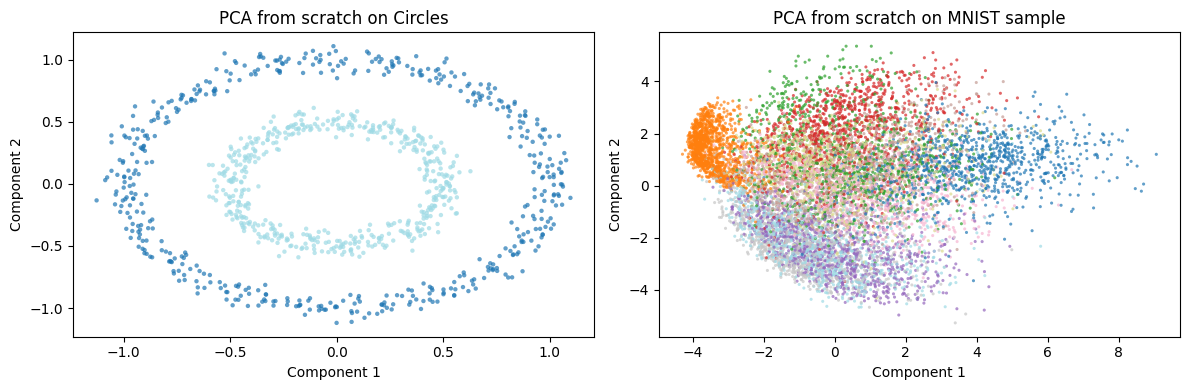

In [9]:
pca_model = ScratchPCA(n_components=2, random_state=SEED)
circles_X_2d_pca = pca_model.fit_transform(circles_X)

mnist_X_sample_scaled = mnist_X_sample / 255.0
pca_mnist_model = ScratchPCA(n_components=2, random_state=SEED)
mnist_X_2d_pca = pca_mnist_model.fit_transform(mnist_X_sample_scaled)

print("MNIST PCA explained variance ratio:", pca_mnist_model.explained_variance_ratio_)
print("MNIST PCA cumulative explained variance:", pca_mnist_model.explained_variance_ratio_.sum())
print("MNIST PCA reconstruction error:", pca_mnist_model.reconstruction_error(mnist_X_sample_scaled))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_embedding_scatter(circles_X_2d_pca, circles_y, title="PCA from scratch on Circles", ax=axes[0], s=10, alpha=0.7, show=False)
plot_embedding_scatter(mnist_X_2d_pca, mnist_y_sample, title="PCA from scratch on MNIST sample", ax=axes[1], s=5, alpha=0.7, show=False)
plt.tight_layout()


**Nhận xét PCA từ output.** Ở hình `PCA from scratch on Circles`, hai lớp vẫn nằm thành hai vòng đồng tâm, tức là PCA gần như chỉ giữ lại hình dạng ban đầu của dữ liệu 2D chứ chưa tạo ra biểu diễn giúp tách tuyến tính hai lớp. Ở hình MNIST, các điểm cùng nhãn có xu hướng tụ lại một phần nhưng vẫn chồng lấn mạnh, cho thấy 2 thành phần chính đầu chưa đủ để tách rõ 10 chữ số. Các dòng `explained_variance_ratio`, `cumulative explained variance` và `reconstruction error` nên được đọc cùng nhau: nếu tổng phương sai giữ lại thấp và lỗi tái tạo còn lớn, embedding 2D chỉ phù hợp để nhìn xu hướng tổng quát, không nên xem là biểu diễn mất mát thấp của MNIST.


[(1, 8.294149747009579, np.float64(0.3619884809992633)),
 (2, 5.797176013598415, np.float64(0.5540633835693531)),
 (3, 4.351104043885918, np.float64(0.6652996889318525)),
 (5, 2.578901941778776, np.float64(0.8016229275554789)),
 (10, 0.4979368102141653, np.float64(0.9616971684450645)),
 (13, 1.1259197214024749e-29, np.float64(1.0000000000000002))]

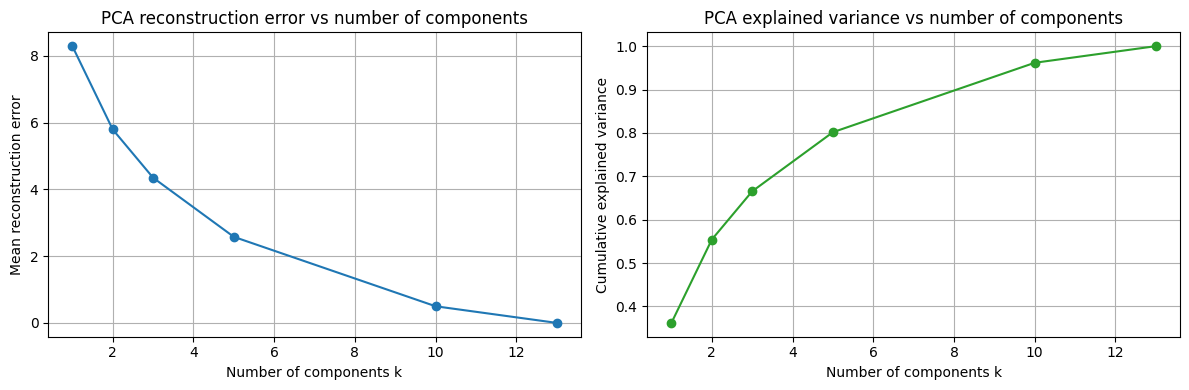

In [10]:
wine = load_wine()
X_wine_scaled = StandardScaler().fit_transform(wine.data)

ks = [1, 2, 3, 5, 10, X_wine_scaled.shape[1]]
errors = []
explained = []

for k in ks:
  model = ScratchPCA(n_components=k, random_state=SEED)
  model.fit(X_wine_scaled)
  errors.append(model.reconstruction_error(X_wine_scaled))
  explained.append(model.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, errors, marker="o")
axes[0].set_xlabel("Number of components k")
axes[0].set_ylabel("Mean reconstruction error")
axes[0].set_title("PCA reconstruction error vs number of components")
axes[0].grid(True)

axes[1].plot(ks, explained, marker="o", color="tab:green")
axes[1].set_xlabel("Number of components k")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("PCA explained variance vs number of components")
axes[1].grid(True)

plt.tight_layout()
list(zip(ks, errors, explained))


**Nhận xét PCA reconstruction từ output.** Khi số thành phần chính `k` tăng, đường reconstruction error giảm, trong khi đường cumulative explained variance tăng. Đây là kiểm chứng trực tiếp cho lý thuyết PCA: giữ lại nhiều thành phần chính hơn đồng nghĩa với giữ lại nhiều phương sai hơn, nên mất mát khi tái dựng dữ liệu nhỏ hơn. Với Wine, số feature là 13 nên điểm cuối dùng `k = 13` thay cho `k = 20`.


## KPCA

KPCA RBF eigenvalues: [151.07450245 150.30995976]


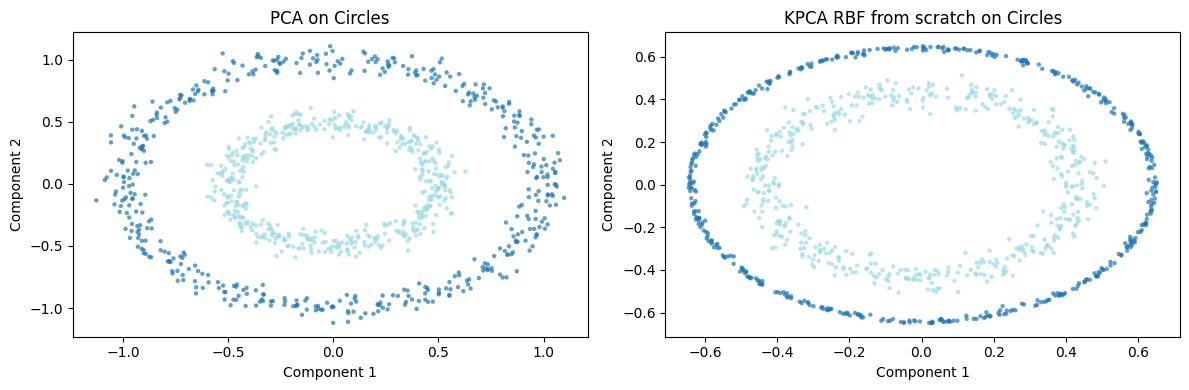

In [11]:
kpca_pca_baseline = ScratchPCA(n_components=2, random_state=SEED)
circles_X_2d_pca_for_kpca = kpca_pca_baseline.fit_transform(circles_X)

kpca_model = ScratchKPCA(n_components=2, kernel="rbf", random_state=SEED)
circles_X_2d_kpca = kpca_model.fit_transform(circles_X)

print("KPCA RBF eigenvalues:", kpca_model.eigenvalues_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_embedding_scatter(circles_X_2d_pca_for_kpca, circles_y, title="PCA on Circles", ax=axes[0], s=10, alpha=0.7, show=False)
plot_embedding_scatter(circles_X_2d_kpca, circles_y, title="KPCA RBF from scratch on Circles", ax=axes[1], s=10, alpha=0.7, show=False)
plt.tight_layout()


**Nhận xét KPCA từ output.** Khi đặt cạnh PCA và KPCA trên `circles`, PCA chỉ thực hiện phép chiếu tuyến tính nên vẫn giữ cấu trúc hai vòng đồng tâm và chưa làm hai lớp trở nên dễ tách tuyến tính. KPCA với RBF kernel ánh xạ dữ liệu sang không gian đặc trưng phi tuyến thông qua kernel, vì vậy embedding thu được phản ánh quan hệ phi tuyến giữa các điểm tốt hơn so với PCA. Hai eigenvalue đầu được in ra cho biết mức đóng góp của hai thành phần kernel chính; việc hai giá trị gần nhau cho thấy hai hướng kernel đầu có vai trò tương đối cân bằng trong embedding 2D.


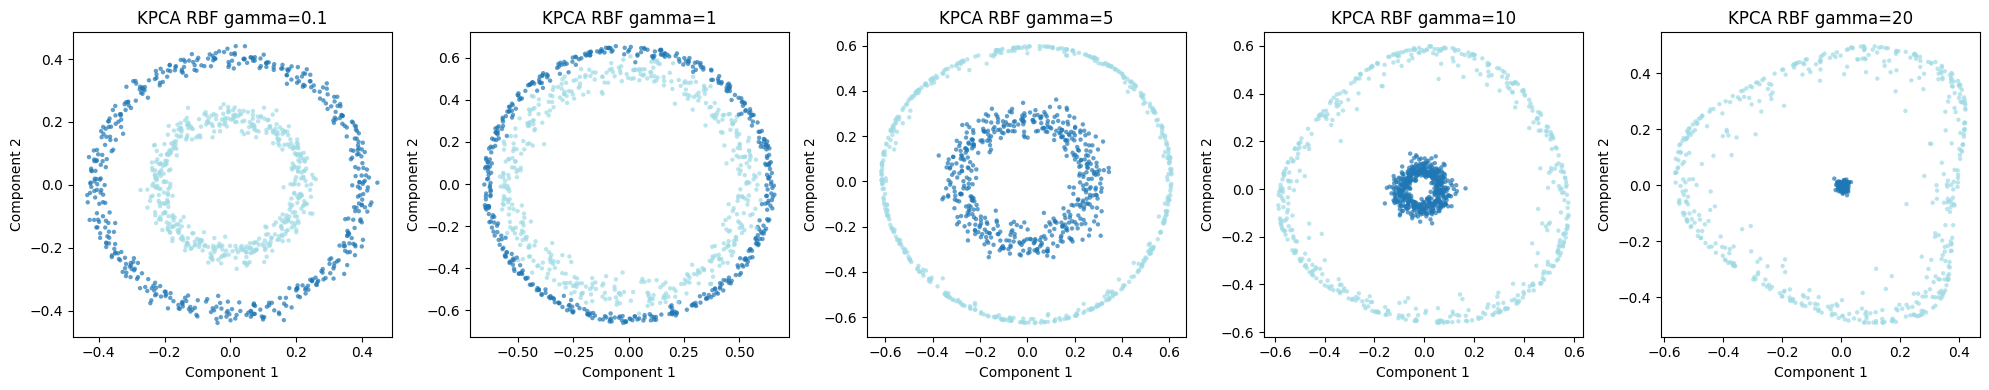

In [12]:
gammas = [0.1, 1, 5, 10, 20]
fig, axes = plt.subplots(1, len(gammas), figsize=(20, 4))

for ax, gamma in zip(axes, gammas):
  kpca = ScratchKPCA(n_components=2, kernel="rbf", gamma=gamma, random_state=SEED)
  Z = kpca.fit_transform(circles_X)
  plot_embedding_scatter(Z, circles_y, title=f"KPCA RBF gamma={gamma}", ax=ax, s=10, alpha=0.7, show=False)

plt.tight_layout()


**Nhận xét gamma sweep từ output.** Các hình cho thấy KPCA phụ thuộc mạnh vào `gamma` của RBF kernel. `gamma` nhỏ làm kernel biến thiên chậm hơn, embedding thường mượt và gần với quan hệ tổng quát hơn. `gamma` lớn làm quan hệ giữa các điểm trở nên rất cục bộ, nên hình có thể bị co cụm hoặc méo mạnh hơn. Vì vậy KPCA không chỉ phụ thuộc vào việc chọn kernel, mà còn phụ thuộc vào hyperparameter của kernel.


## Isomap


Isomap geodesic distance matrix: (1500, 1500)
All geodesic distances finite: True


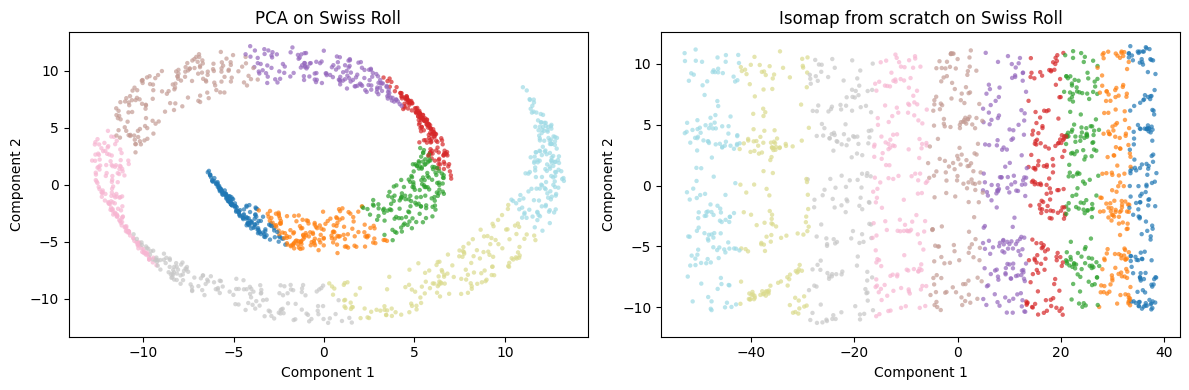

In [13]:
isomap_model = ScratchIsomap(n_neighbors=12, n_components=2, random_state=SEED)
swiss_roll_X_2d_isomap = isomap_model.fit_transform(swiss_roll_X)

pca_swiss_model = ScratchPCA(n_components=2, random_state=SEED)
swiss_roll_X_2d_pca = pca_swiss_model.fit_transform(swiss_roll_X)

print("Isomap geodesic distance matrix:", isomap_model.geodesic_distances_.shape)
print("All geodesic distances finite:", np.isfinite(isomap_model.geodesic_distances_).all())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_embedding_scatter(swiss_roll_X_2d_pca, swiss_roll_y, title="PCA on Swiss Roll", ax=axes[0], s=10, alpha=0.7, show=False)
plot_embedding_scatter(swiss_roll_X_2d_isomap, swiss_roll_y, title="Isomap from scratch on Swiss Roll", ax=axes[1], s=10, alpha=0.7, show=False)
plt.tight_layout()


**Nhận xét Isomap từ output.** Hình so sánh Swiss Roll cho thấy PCA vẫn giữ dạng cong/cuộn vì nó chỉ tìm mặt phẳng tuyến tính tốt nhất trong không gian 3D. Ngược lại, Isomap cho embedding được trải ra thành một miền phẳng hơn, màu thay đổi có trật tự hơn theo chiều cuộn. Đây là dấu hiệu tốt: Isomap đang dùng khoảng cách đường đi trên đồ thị để đi dọc manifold thay vì đo khoảng cách thẳng xuyên qua cuộn. Dòng `All geodesic distances finite: True` xác nhận đồ thị láng giềng liên thông, nên kết quả Isomap không bị lỗi do các thành phần rời rạc.

Điều này phù hợp với mô tả lý thuyết của Isomap: thuật toán thay khoảng cách Euclidean trực tiếp bằng khoảng cách geodesic xấp xỉ trên đồ thị láng giềng, sau đó dùng double centering và phân rã trị riêng để lấy biểu diễn thấp chiều.


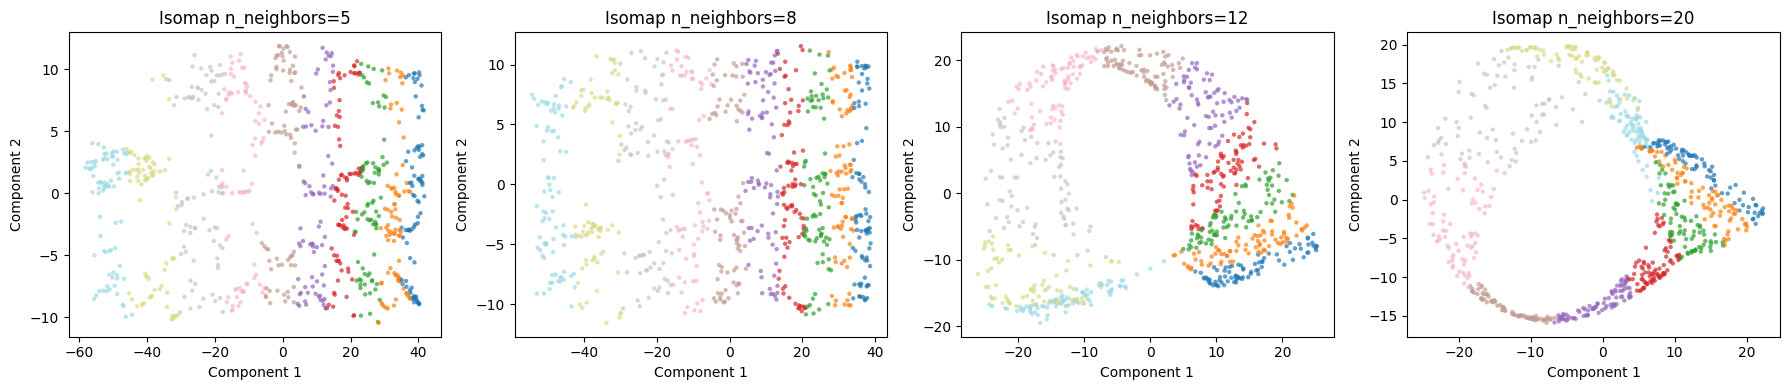

In [14]:
neighbors_list = [5, 8, 12, 20]
isomap_sweep_size = min(800, len(swiss_roll_X))
isomap_sweep_rng = np.random.default_rng(SEED)
isomap_sweep_idx = isomap_sweep_rng.choice(len(swiss_roll_X), size=isomap_sweep_size, replace=False)
X_swiss_sweep = swiss_roll_X[isomap_sweep_idx]
color_swiss_sweep = swiss_roll_y[isomap_sweep_idx]

fig, axes = plt.subplots(1, len(neighbors_list), figsize=(18, 4))

for ax, n_neighbors in zip(axes, neighbors_list):
  iso = ScratchIsomap(n_neighbors=n_neighbors, n_components=2, random_state=SEED)
  Z = iso.fit_transform(X_swiss_sweep)
  plot_embedding_scatter(Z, color_swiss_sweep, title=f"Isomap n_neighbors={n_neighbors}", ax=ax, s=10, alpha=0.7, show=False)

plt.tight_layout()


**Nhận xét Isomap neighbor sweep từ output.** Các hình cho thấy Isomap nhạy với số láng giềng. Nếu `n_neighbors` quá nhỏ, đồ thị láng giềng dễ thiếu cạnh, khiến geodesic distance không ổn định hoặc embedding bị đứt đoạn. Nếu `n_neighbors` quá lớn, đồ thị có nhiều cạnh tắt nối xuyên qua manifold, làm khoảng cách geodesic tiến gần khoảng cách Euclidean và giảm khả năng “mở cuộn”. Cấu hình tốt là mức vừa đủ để đồ thị liên thông nhưng vẫn giữ cấu trúc cục bộ của Swiss Roll.


## LLE

In [15]:
# Initialize LLE for a 2D embedding from local neighborhoods.
lle_model = LLE(
  n_neighbors=12, 
  n_components=2, 
  reg=1e-3
)

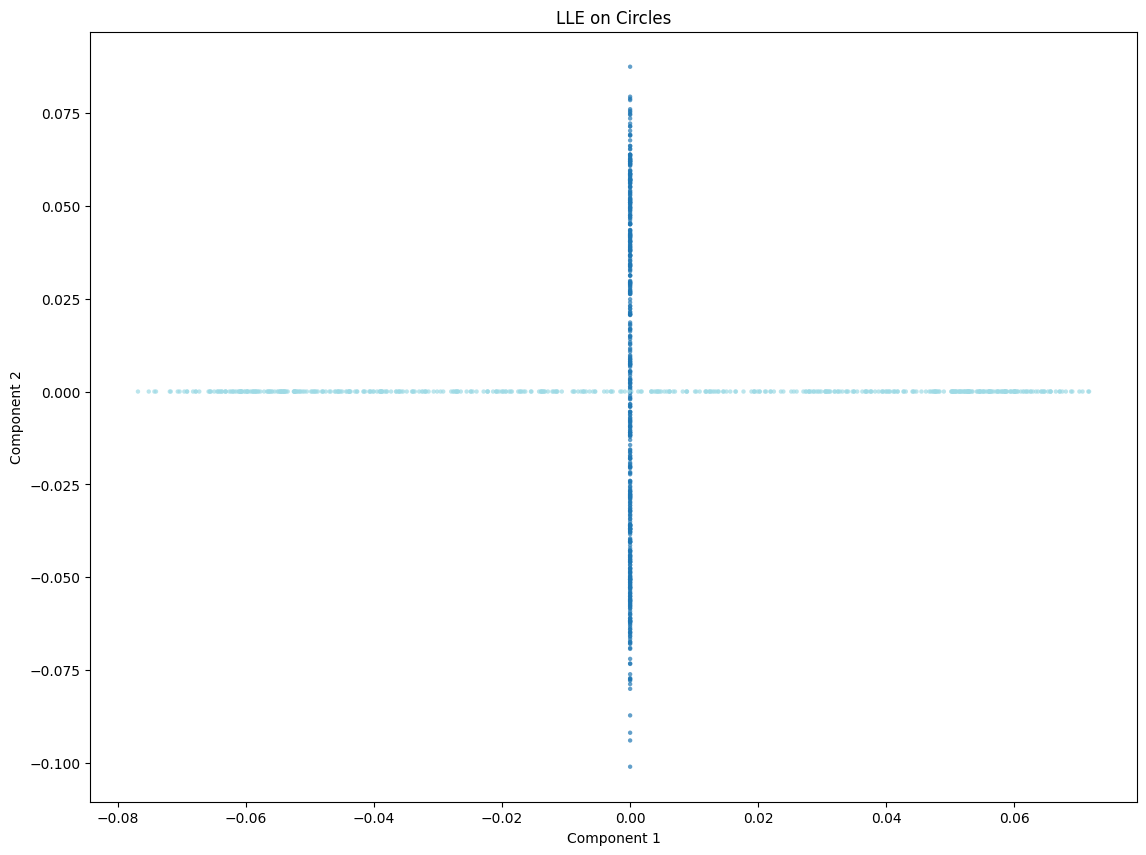

<Axes: title={'center': 'LLE on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [16]:
# Run LLE on circles and plot the 2D embedding colored by label.
circles_X_2d_lle = lle_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_lle, circles_y, title="LLE on Circles", s=10, alpha=0.7)

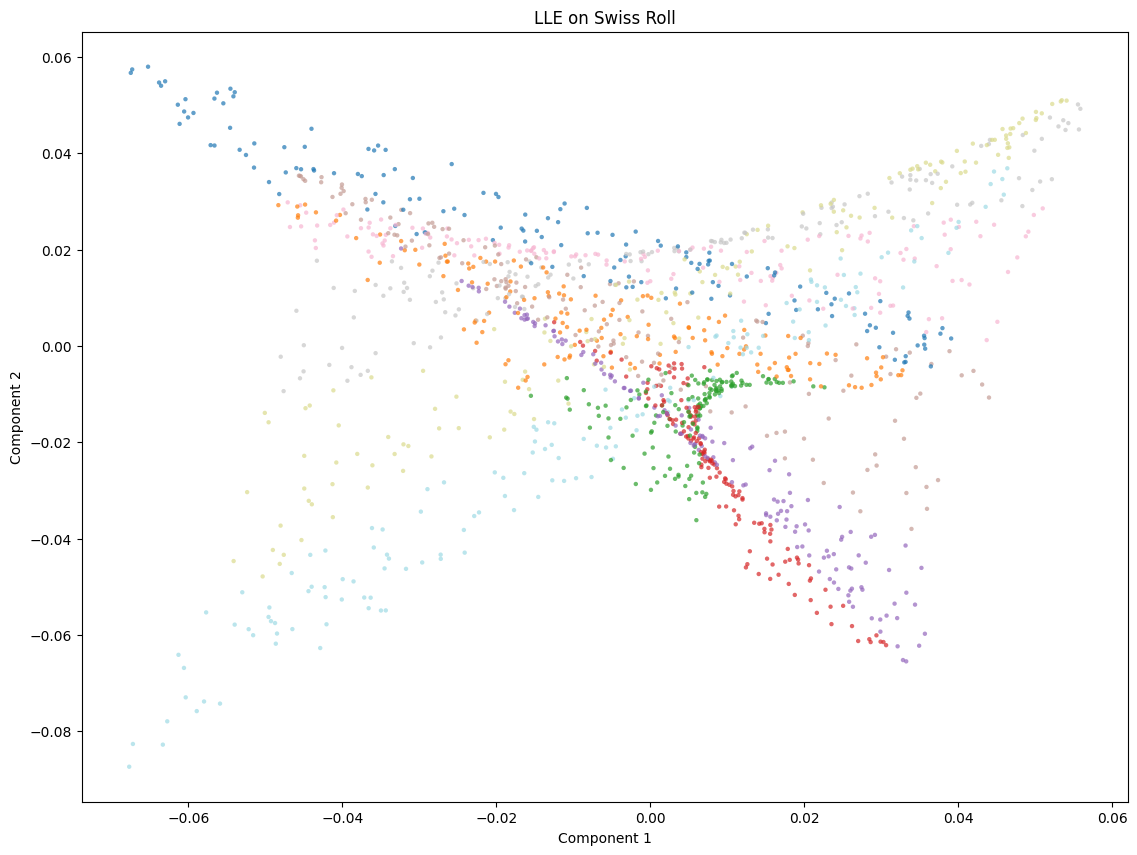

<Axes: title={'center': 'LLE on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [17]:
# Run LLE on swiss roll to test unfolding of the 3D manifold.
swiss_roll_X_2d_lle = lle_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_lle, swiss_roll_y, title="LLE on Swiss Roll", s=10, alpha=0.7)

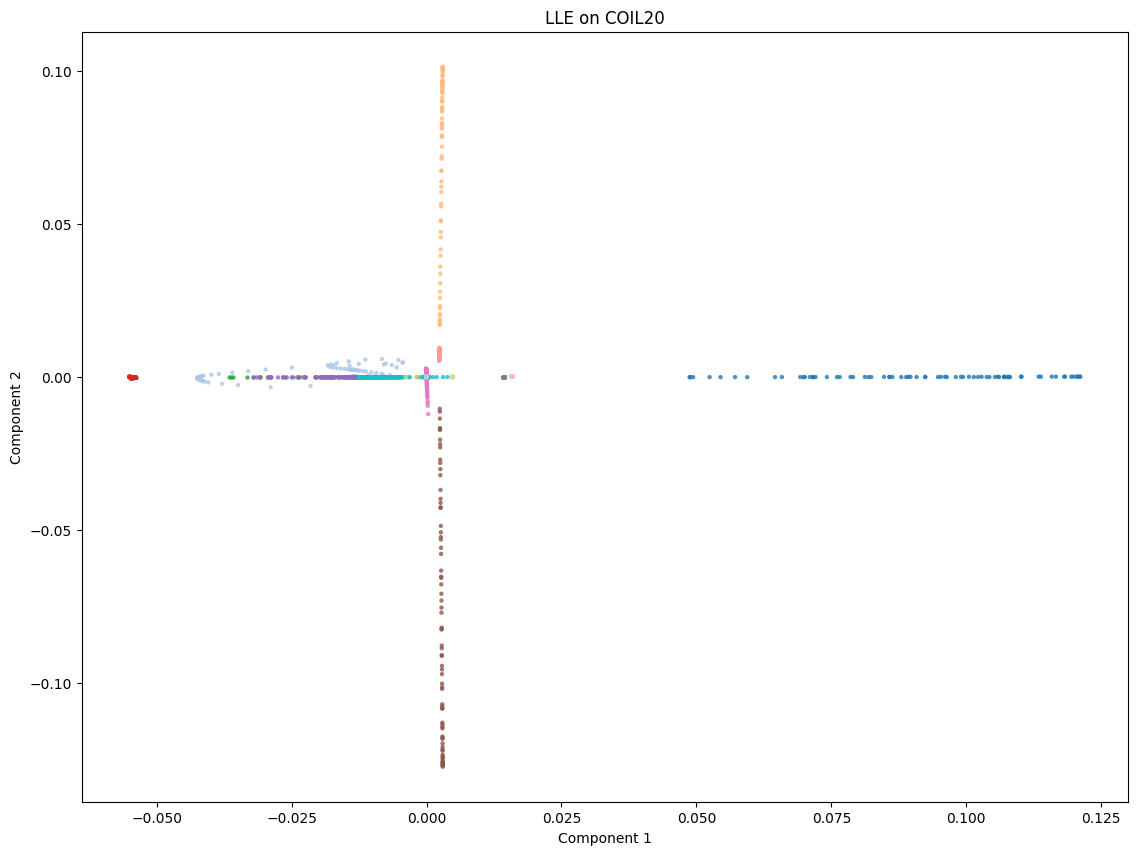

<Axes: title={'center': 'LLE on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [18]:
# Reduce COIL-20 with LLE and inspect class separation.
coil20_X_2d_lle = lle_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_lle, coil20_y, title="LLE on COIL20", s=10)

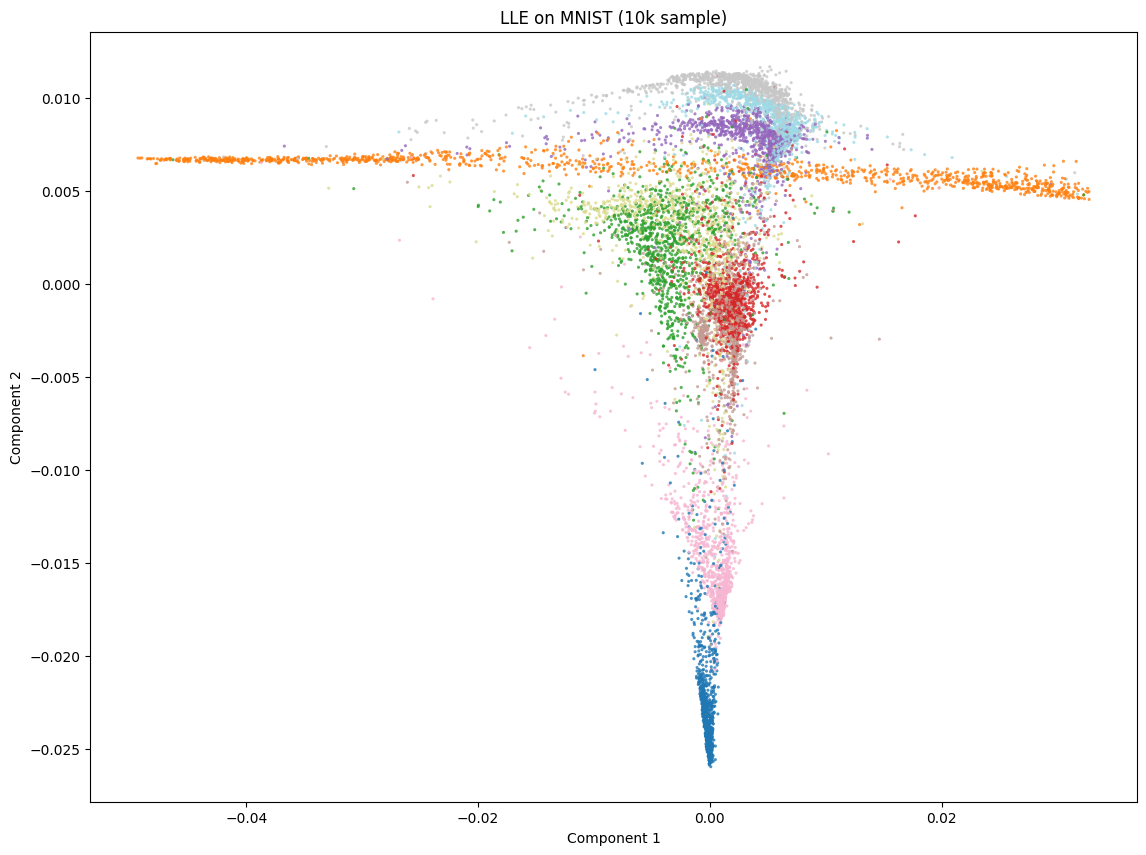

<Axes: title={'center': 'LLE on MNIST (10k sample)'}, xlabel='Component 1', ylabel='Component 2'>

In [19]:
# Run LLE on the 10k MNIST sample to reduce compute cost.
mnist_X_2d_lle = lle_model.fit_transform(mnist_X_sample)
plot_embedding_scatter(mnist_X_2d_lle, mnist_y_sample, title="LLE on MNIST (10k sample)", s=5)

### Nhận xét

- **Circles:** LLE giữ được cấu trúc cục bộ của hai vòng tròn, nhưng embedding 2D có thể làm biến dạng hình dạng tổng thể. Các điểm cùng nhãn vẫn nằm gần nhau tương đối rõ, phù hợp với mục tiêu bảo toàn láng giềng.
- **Swiss roll:** Swiss roll được trải phẳng thành không gian 2D với gradient màu khá liên tục. Một số vùng biên có thể bị cong hoặc nén lại, cho thấy LLE nhạy với cách chọn số láng giềng.
- **COIL-20:** COIL-20 tạo ra một vài cụm theo đối tượng, nhưng các cụm vẫn chồng lấp do ảnh có số chiều lớn và thay đổi theo góc quay. LLE chủ yếu bảo toàn quan hệ cục bộ nên khả năng tách lớp không hoàn toàn rõ ràng.
- **MNIST (10k mẫu):** MNIST sau LLE có các nhóm chữ số tương đối riêng biệt, nhưng nhiều chữ số có nét viết gần nhau vẫn bị lẫn. Kết quả trên mẫu 10k giúp giảm chi phí tính toán, đổi lại có thể mất một phần cấu trúc của toàn bộ tập dữ liệu.


## Laplacian Eigenmaps

In [20]:
# Initialize Laplacian Eigenmaps: k-NN graph and 2D embedding from the Laplacian spectrum.
laplacian_model = LaplacianEigenmaps(
  n_neighbors=15, 
  n_components=2, 
  sigma=5.0
)

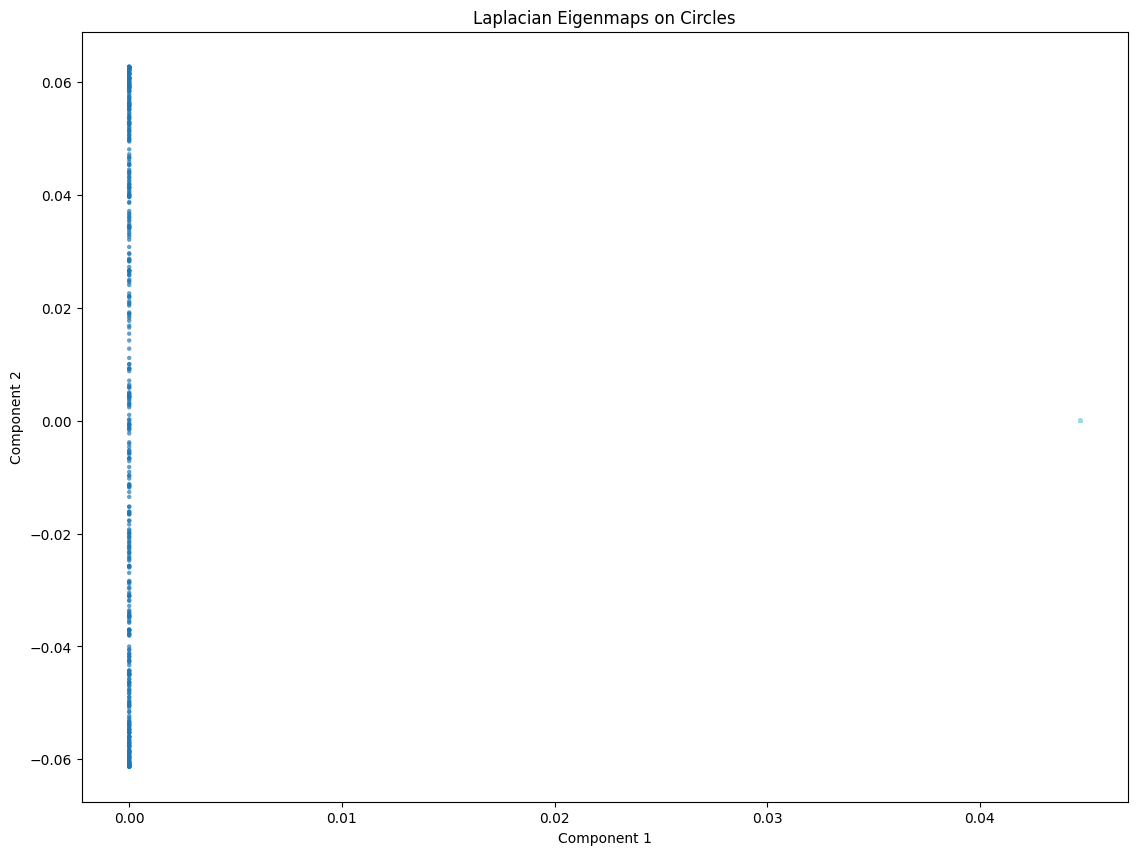

<Axes: title={'center': 'Laplacian Eigenmaps on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [21]:
# Run Laplacian Eigenmaps on circles and visualize the result.
circles_X_2d_le = laplacian_model.fit_transform(circles_X)
plot_embedding_scatter(circles_X_2d_le, circles_y, title="Laplacian Eigenmaps on Circles", s=10, alpha=0.7)

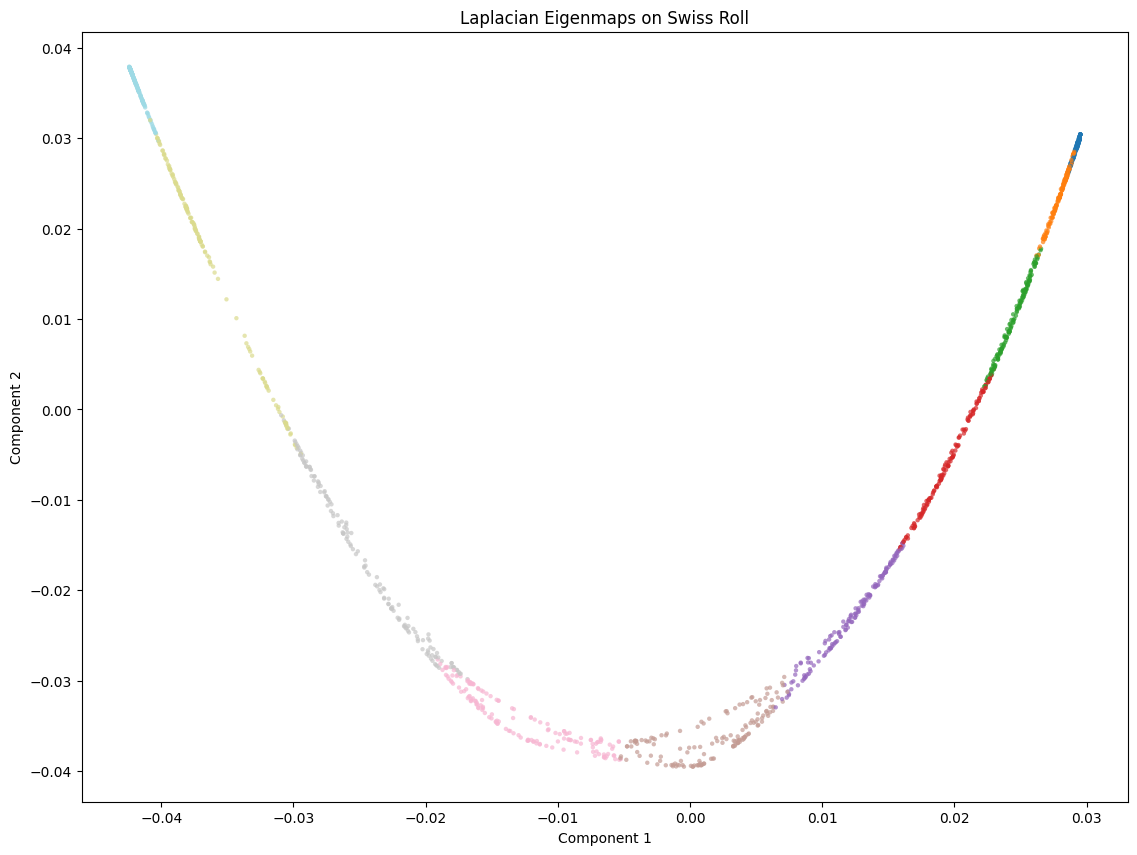

<Axes: title={'center': 'Laplacian Eigenmaps on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [22]:
# Run Laplacian Eigenmaps on swiss roll for comparison with LLE.
swiss_roll_X_2d_le = laplacian_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_X_2d_le, swiss_roll_y, title="Laplacian Eigenmaps on Swiss Roll", s=10, alpha=0.7)

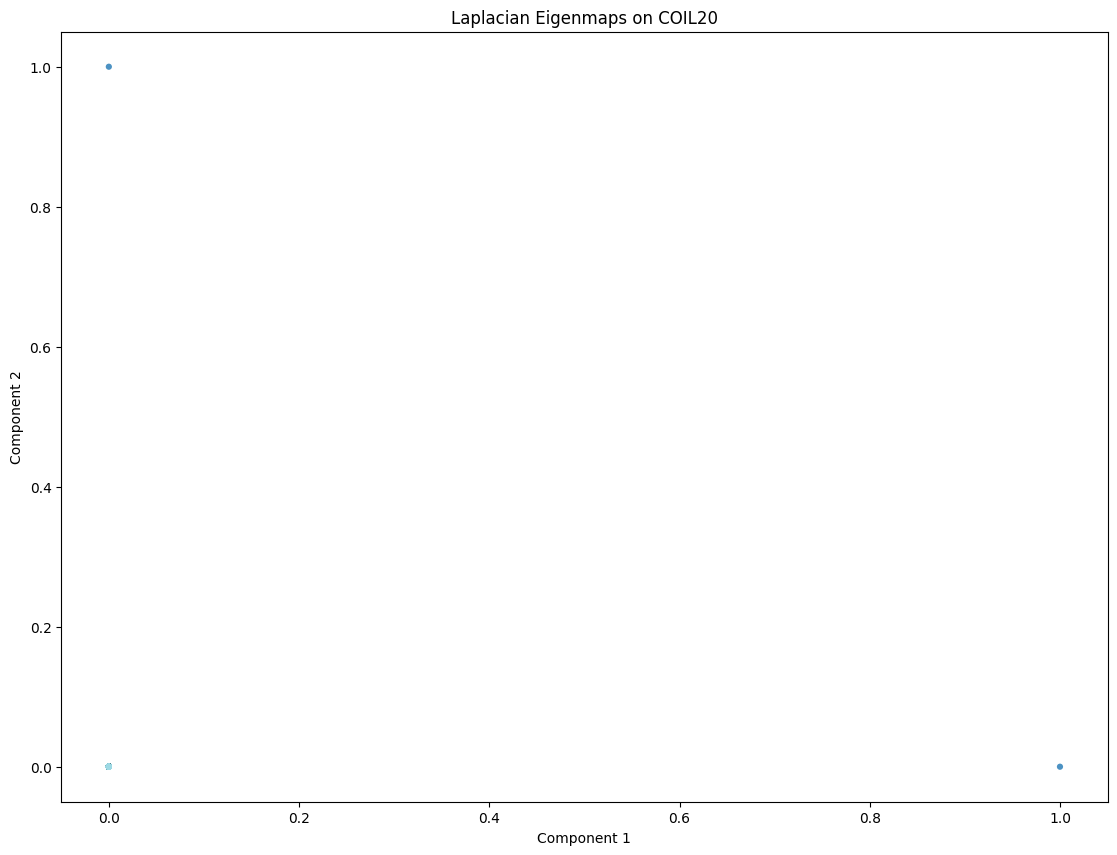

<Axes: title={'center': 'Laplacian Eigenmaps on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [23]:
# Run Laplacian Eigenmaps on flattened COIL-20 images.
coil20_X_2d_le = laplacian_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_X_2d_le, coil20_y, title="Laplacian Eigenmaps on COIL20", s=20, alpha=0.7)

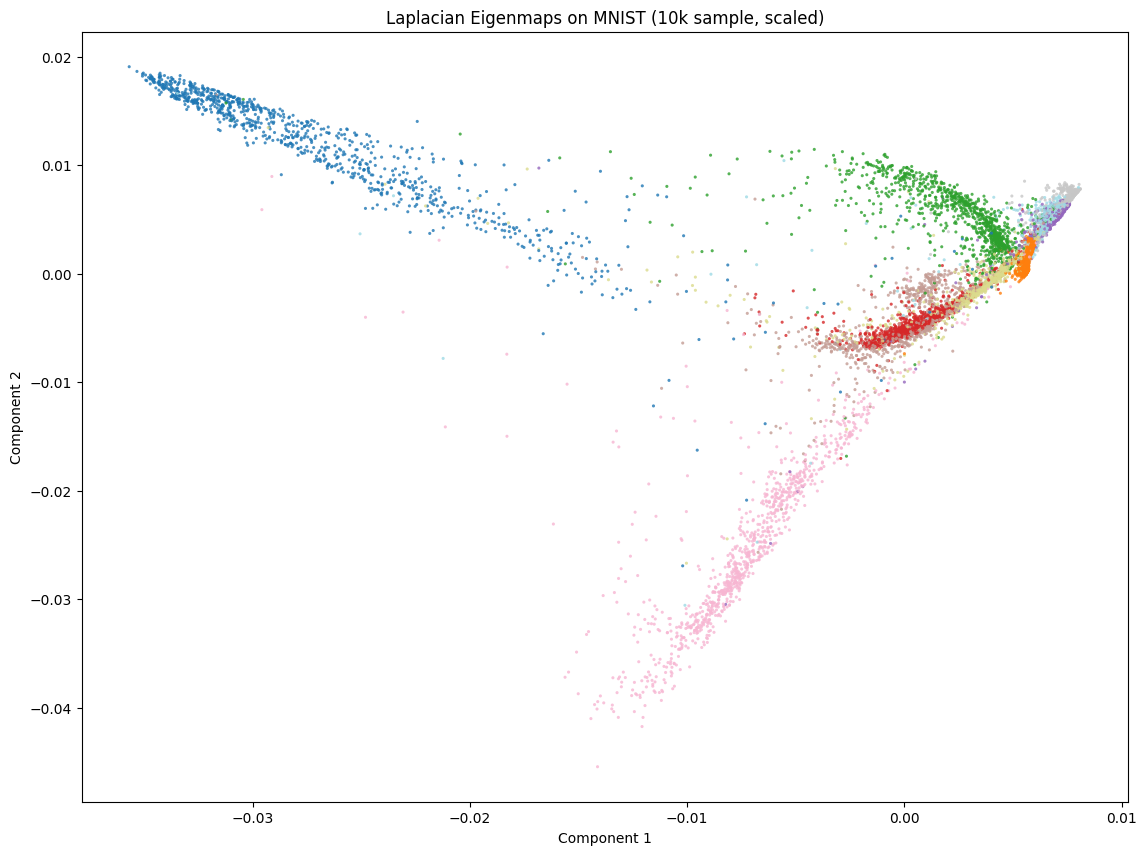

<Axes: title={'center': 'Laplacian Eigenmaps on MNIST (10k sample, scaled)'}, xlabel='Component 1', ylabel='Component 2'>

In [24]:
# Scale MNIST pixels to [0, 1] before distances for Laplacian Eigenmaps.
mnist_X_sample_scaled = mnist_X_sample / 255.0
mnist_X_2d_le = laplacian_model.fit_transform(mnist_X_sample_scaled)
plot_embedding_scatter(mnist_X_2d_le, mnist_y_sample, title="Laplacian Eigenmaps on MNIST (10k sample, scaled)", s=5, alpha=0.7)

### Nhận xét

- **Circles:** Laplacian Eigenmaps biểu diễn dữ liệu dựa trên đồ thị láng giềng, nên các điểm liên thông cục bộ được giữ gần nhau. Với circles, cấu trúc hai vòng có thể hiện rõ nhưng hình dạng tổng thể phụ thuộc mạnh vào đồ thị k-NN.
- **Swiss roll:** Embedding của swiss roll có sự chuyển màu khá mượt, cho thấy quan hệ lân cận trên manifold được bảo toàn. Nếu có vùng bị chồng hoặc bị kéo dài, đó là dấu hiệu tham số láng giềng/sigma ảnh hưởng đến trọng số cạnh của đồ thị.
- **COIL-20:** Trên COIL-20, Laplacian Eigenmaps gom được một số ảnh gần nhau về mặt thị giác, nhưng các lớp đối tượng chưa tách thành các cụm sạch. Điều này dễ xảy ra khi khoảng cách Euclidean trên pixel chưa nắm bắt hết khác biệt ngữ nghĩa giữa đối tượng.
- **MNIST (10k mẫu, scale [0, 1]):** Việc scale pixel về [0, 1] giúp khoảng cách ổn định hơn trước khi lập đồ thị. Các chữ số có xu hướng gom cụm, nhưng những cặp dễ nhầm lẫn như 4/9, 3/5 hoặc 7/9 vẫn có thể nằm gần nhau.


## t-SNE

**[MỞ RỘNG]** Phần t-SNE được dùng để so sánh thực nghiệm và khảo sát độ nhạy theo `perplexity`. Thuật toán này gọi `sklearn.manifold.TSNE`, không dùng để thay thế yêu cầu cài đặt from scratch. Các thuật toán from scratch chính của nhóm là PCA, KPCA và Isomap.


Running t-SNE perplexity=5...
Running t-SNE perplexity=10...
Running t-SNE perplexity=30...
Running t-SNE perplexity=50...


[{'method': 't-SNE perplexity=5',
  'trustworthiness@12': 0.941,
  'knn_accuracy@5': 0.869},
 {'method': 't-SNE perplexity=10',
  'trustworthiness@12': 0.9548,
  'knn_accuracy@5': 0.872},
 {'method': 't-SNE perplexity=30',
  'trustworthiness@12': 0.9544,
  'knn_accuracy@5': 0.883},
 {'method': 't-SNE perplexity=50',
  'trustworthiness@12': 0.9485,
  'knn_accuracy@5': 0.868}]

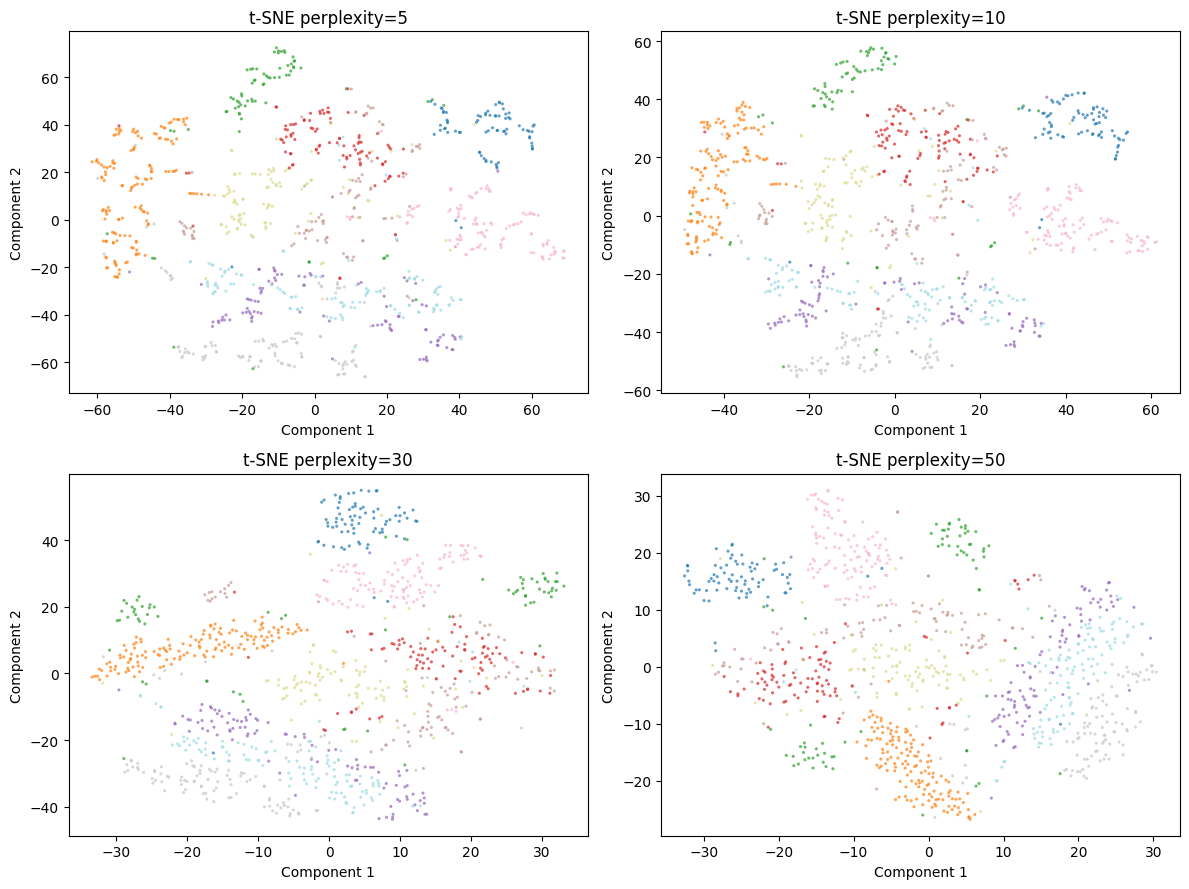

In [25]:
def embedding_knn_accuracy(Y, y, n_neighbors=5):
  y = np.asarray(y)
  k = min(n_neighbors + 1, len(Y))
  neighbors = NearestNeighbors(n_neighbors=k).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
  pred = []
  for row in neighbors:
    values, counts = np.unique(y[row], return_counts=True)
    pred.append(values[np.argmax(counts)])
  return float(np.mean(np.asarray(pred) == y))


tsne_sample_size = 1_000
tsne_sample_rng = np.random.default_rng(SEED)
tsne_sample_idx = tsne_sample_rng.choice(len(mnist_X), size=tsne_sample_size, replace=False)
tsne_X_sample = mnist_X[tsne_sample_idx] / 255.0
tsne_y_sample = mnist_y[tsne_sample_idx]

tsne_perplexities = [5, 10, 30, 50]
tsne_embeddings = {}
tsne_metrics = []

for perplexity in tsne_perplexities:
  label = f"t-SNE perplexity={perplexity}"
  print(f"Running {label}...")
  model = ScratchTSNE(
    n_components=2,
    perplexity=perplexity,
    max_iter=750,
    init="pca",
    random_state=SEED,
  )
  Y = model.fit_transform(tsne_X_sample)
  tsne_embeddings[label] = Y
  tsne_metrics.append({
    "method": label,
    "trustworthiness@12": round(float(trustworthiness(tsne_X_sample, Y, n_neighbors=12)), 4),
    "knn_accuracy@5": round(embedding_knn_accuracy(Y, tsne_y_sample, n_neighbors=5), 4),
  })

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (label, Y) in zip(axes.ravel(), tsne_embeddings.items()):
  plot_embedding_scatter(Y, tsne_y_sample, title=label, ax=ax, s=5, alpha=0.7, show=False)
plt.tight_layout()

tsne_metrics


**Nhận xét t-SNE từ output.** Bốn hình t-SNE với `perplexity = 5, 10, 30, 50` nên được so sánh trực tiếp: nếu `perplexity` nhỏ, embedding thường tách thành nhiều cụm nhỏ và nhấn mạnh lân cận rất cục bộ; khi `perplexity` lớn hơn, các cụm có xu hướng gom mượt hơn nhưng có thể trộn một số nhãn. Bảng `tsne_metrics` giúp chọn cấu hình dựa trên số liệu thay vì chỉ nhìn hình: cấu hình nào có `trustworthiness@12` cao hơn thì giữ lân cận cục bộ tốt hơn, cấu hình nào có `knn_accuracy@5` cao hơn thì nhãn digit được bảo toàn tốt hơn trong embedding 2D. Khi báo cáo, nên nêu cấu hình tốt nhất theo bảng metric của lần chạy hiện tại, thay vì khẳng định một perplexity luôn tốt nhất cho mọi dữ liệu.


## UMAP

In [26]:
from umap import UMAP

# Initialize UMAP with a fixed seed for more stable embeddings across runs.
umap_model = UMAP(
  n_neighbors=15,
  min_dist=0.1,
  n_components=2,
  metric='euclidean',
  random_state=SEED
)

/home/tamle/csc14005-introduction-to-machine-learning/lab-2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  warn(


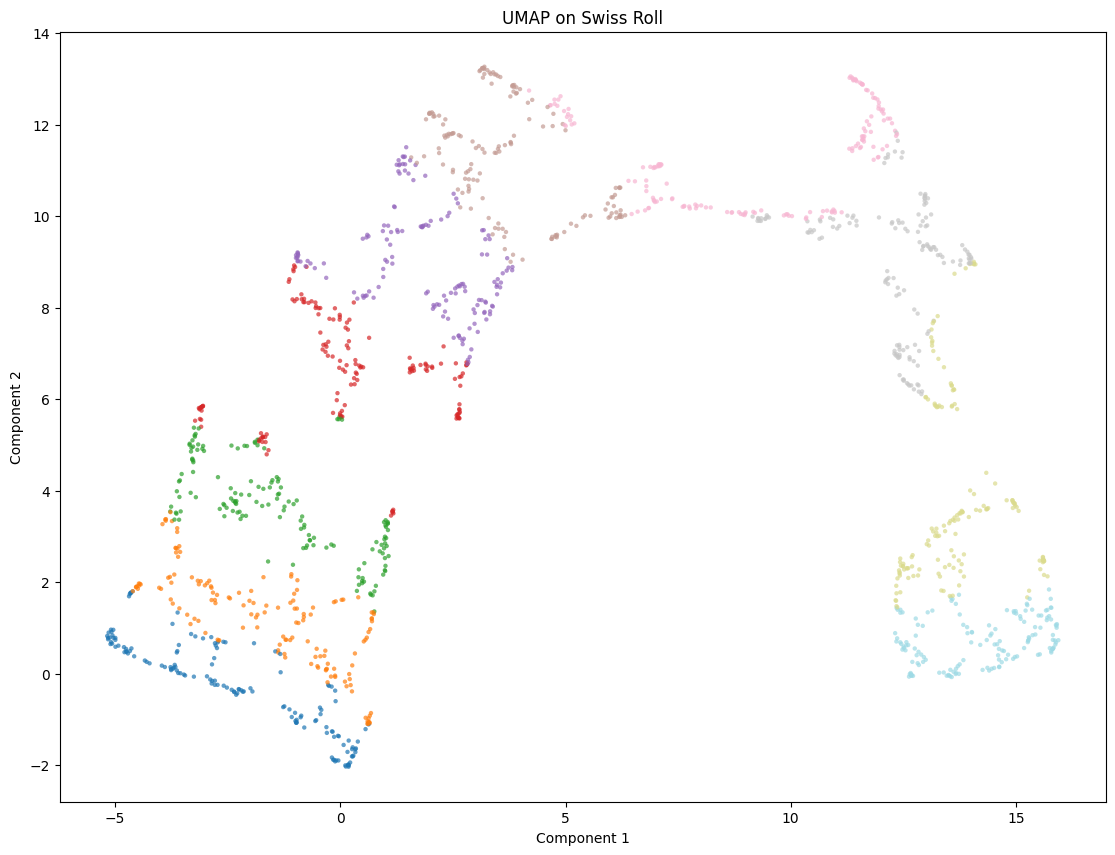

<Axes: title={'center': 'UMAP on Swiss Roll'}, xlabel='Component 1', ylabel='Component 2'>

In [27]:
# Run UMAP on swiss roll and plot the 2D embedding.
swiss_roll_2d = umap_model.fit_transform(swiss_roll_X)
plot_embedding_scatter(swiss_roll_2d, swiss_roll_y, title="UMAP on Swiss Roll", s=10, alpha=0.7)

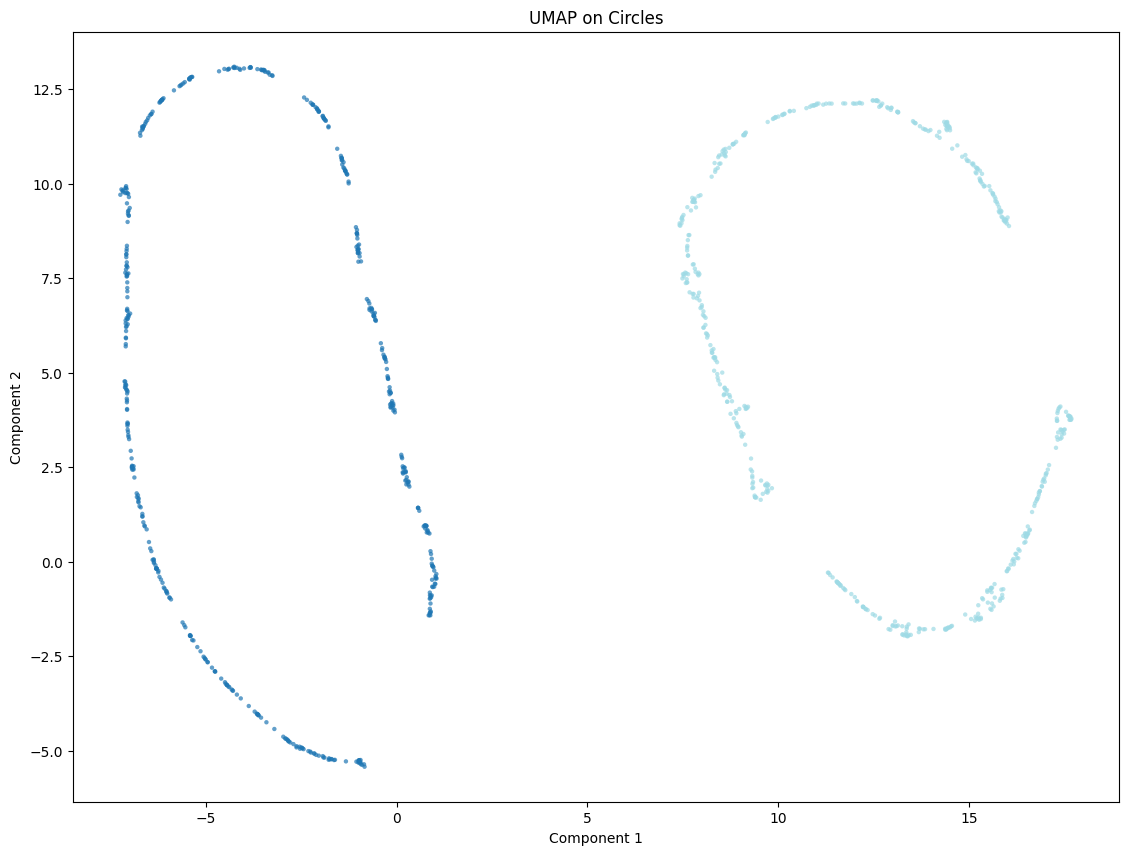

<Axes: title={'center': 'UMAP on Circles'}, xlabel='Component 1', ylabel='Component 2'>

In [28]:
# Run UMAP on circles to inspect nonlinear structure preservation.
circles_2d = umap_model.fit_transform(circles_X)
plot_embedding_scatter(circles_2d, circles_y, title="UMAP on Circles", s=10, alpha=0.7)

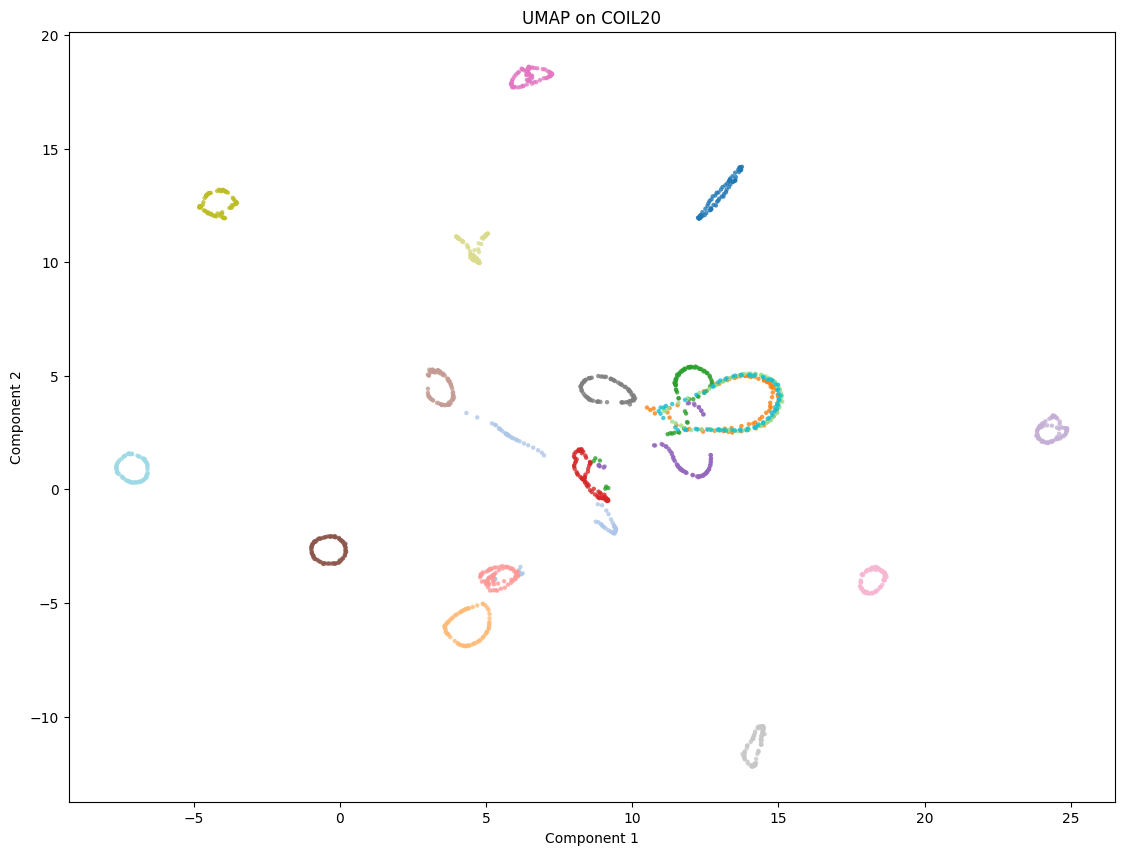

<Axes: title={'center': 'UMAP on COIL20'}, xlabel='Component 1', ylabel='Component 2'>

In [29]:
# Run UMAP on COIL-20 and color by object label.
coil20_2d = umap_model.fit_transform(coil20_X)
plot_embedding_scatter(coil20_2d, coil20_y, title="UMAP on COIL20", s=10)

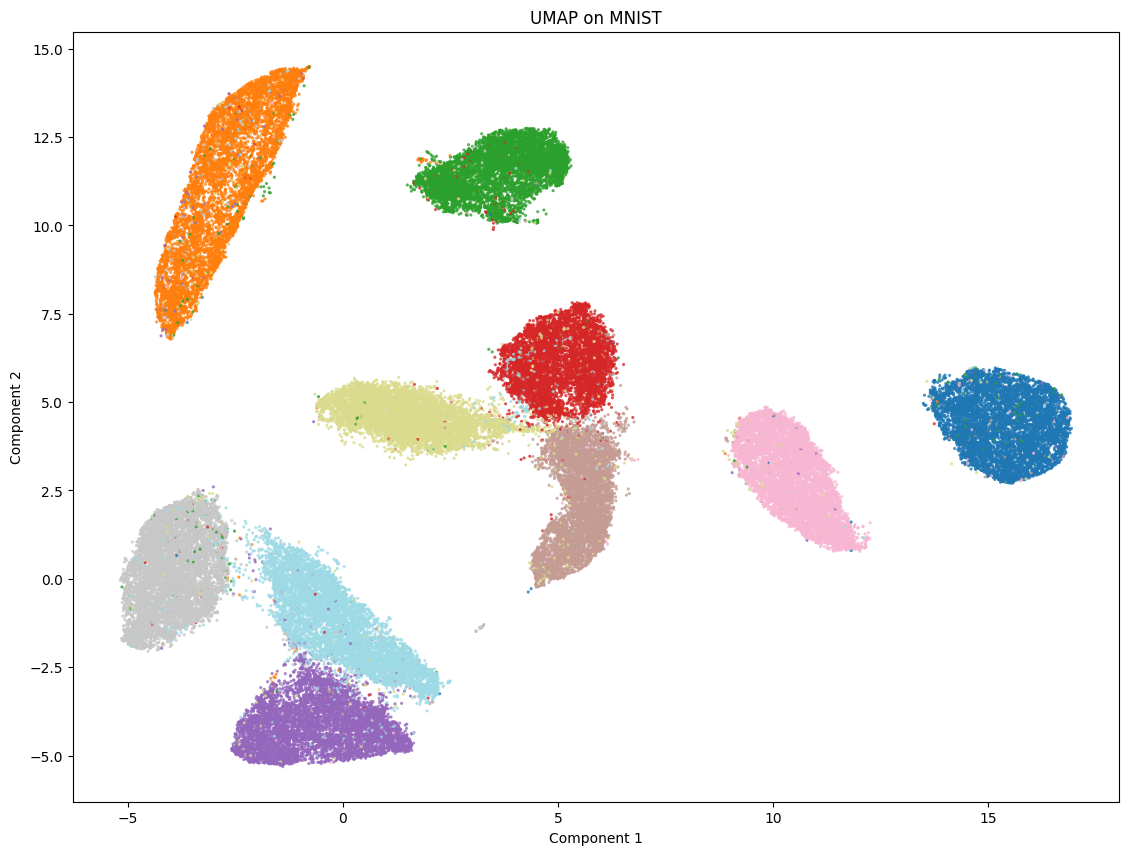

<Axes: title={'center': 'UMAP on MNIST'}, xlabel='Component 1', ylabel='Component 2'>

In [30]:
# Run UMAP on full MNIST to view digit clusters in 2D.
mnist_X_2d = umap_model.fit_transform(mnist_X)
plot_embedding_scatter(mnist_X_2d, mnist_y, title="UMAP on MNIST", s=5)

### Nhận xét

- **Circles:** UMAP tách hai vòng/các nhóm điểm khá rõ trong không gian 2D. So với các phương pháp đồ thị phổ, embedding này dễ nhìn hơn cho mục tiêu trực quan hóa cụm.
- **Swiss roll:** UMAP thường trải swiss roll thành mặt phẳng rõ và liên tục hơn, với các màu thay đổi theo thứ tự manifold. Kết quả cho thấy UMAP bảo toàn được cả cấu trúc cục bộ lẫn một phần cấu trúc toàn cục.
- **COIL-20:** COIL-20 với UMAP tạo các cụm đối tượng rõ hơn, nhưng vẫn có một số cụm gần nhau do các ảnh có góc nhìn liên tiếp hoặc đặc trưng pixel tương tự. UMAP phù hợp cho trực quan hóa dữ liệu ảnh hơn khi cần thấy cấu trúc cụm.
- **MNIST (toàn bộ tập):** UMAP trên MNIST tạo các cụm chữ số khá tách biệt, thể hiện rõ cấu trúc lớp trong dữ liệu. Những chữ số có hình dạng gần nhau vẫn có vùng tiếp giáp hoặc chồng lấp, điều này phản ánh sự tương đồng tự nhiên của chữ viết tay.


# Bảng nhận xét tổng hợp

| Thuật toán | Circles | Swiss roll | COIL-20 | MNIST | Đánh giá chung |
|------------|---------|------------|---------|-------|----------------|
| PCA | — | — | — | — | *(chờ thí nghiệm)* |
| KPCA | — | — | — | — | *(chờ thí nghiệm)* |
| LLE | Giữ cấu trúc cục bộ hai vòng; có thể biến dạng hình tổng thể | Trải phẳng mượt; nhạy số láng giềng ở vùng biên | Vài cụm theo đối tượng nhưng còn chồng lấp | Nhóm chữ số tách tương đối; dễ lẫn nét gần nhau (10k) | Bảo toàn láng giềng cục bộ; tách lớp trung bình trên ảnh/MNIST |
| Laplacian Eigenmaps | Hai vòng thấy được; phụ thuộc đồ thị k-NN | Chuyển màu mượt; tham số ảnh hưởng vùng chồng/kéo | Gom ảnh gần nhau nhưng lớp chưa tách sạch | Gom cụm sau scale; cặp 4/9, 3/5, 7/9 vẫn gần (10k) | Đồ thị láng giềng; tương tự LLE, pixel distance hạn chế trên COIL-20 |
| t-SNE | — | — | — | — | *(chờ thí nghiệm)* |
| UMAP | Tách hai vòng rõ; dễ nhìn cho cụm | Trải phẳng rõ, giữ cả cục bộ và một phần toàn cục | Cụm đối tượng rõ hơn; vẫn có cụm gần nhau | Cụm chữ số tách biệt; chữ tương tự còn tiếp giáp (full) | Trực quan cụm tốt nhất trong các phương pháp đã chạy |
